In [ ]:

import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



In [ ]:

# Load the dataset
df = pd.read_csv('segment_fix_nov2024.csv')
df

,uid,occupation,city,province,age,gender,monetary,frequency,fees,basket_size
0,2265026,pegawai negeri,Kab. Bulungan,Kalimantan Utara,47,Male,3.525132e+08,61.0,900300.000000,5.778905e+06
1,6362833,TNI/POLRI,Kota Tarakan,Kalimantan Utara,29,Male,1.882760e+05,12.0,178.000000,1.568967e+04
2,3011228,pelajar/mahasiswa,Kota Ambon,Maluku,23,Male,2.005598e+08,460.0,137964.000000,4.359996e+05
3,2990647,pelajar/mahasiswa,Kab. Konawe Selatan,Sulawesi Tenggara,25,Male,5.416335e+06,11.0,4642.000000,4.923941e+05
4,3646259,karyawan swasta,Kab. Ende,Nusa Tenggara Timur,35,Male,5.855910e+05,11.0,287.000000,5.323555e+04
...,...,...,...,...,...,...,...,...,...,...
102394,4671998,wiraswasta,Kota Sabang,Aceh,33,Male,4.606962e+07,20.0,122951.811145,2.303481e+06
102395,4852583,lainnya,Kab. Aceh Utara,Aceh,28,Male,2.569150e+06,12.0,3737.220102,2.140958e+05
102396,798302,wiraswasta,Kota Banda Aceh,Aceh,42,Male,2.484332e+07,28.0,30.000000,8.872614e+05
102397,1292851,karyawan swasta,Kota Langsa,Aceh,46,Female,9.008400e+05,1.0,0.000000,9.008400e+05


In [ ]:
# Calculate descriptive statistics for frequency
frequency_stats = df['frequency'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
frequency_stats

,frequency
count,1.023980e+05
mean,2.713001e+02
std,2.136591e+04
min,1.000000e+00
50%,2.000000e+01
75%,6.800000e+01
90%,2.043000e+02
95%,4.050000e+02
99%,1.595030e+03
max,5.379594e+06


In [ ]:
# Calculate descriptive statistics for monetary
monetary_stats = df['monetary'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
monetary_stats

,monetary
count,1.023980e+05
mean,9.063995e+08
std,9.410783e+10
min,1.000000e+04
50%,3.976189e+06
75%,3.270394e+07
90%,2.647324e+08
95%,8.710676e+08
99%,6.451197e+09
max,2.760674e+13


In [ ]:
# Calculate percentiles for frequency
frequency_percentiles = df['frequency'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])
print(frequency_percentiles)



0.50      20.00
0.75      68.00
0.90     204.30
0.95     405.00
0.99    1595.03
Name: frequency, dtype: float64


In [ ]:

# Calculate percentiles for monetary
monetary_percentiles = df['monetary'].quantile([0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.9, 0.95, 0.99])
monetary_percentiles

,monetary
0.60,8.495818e+06
0.65,1.284402e+07
0.70,2.007282e+07
0.75,3.270394e+07
0.80,5.759316e+07
0.85,1.132959e+08
0.90,2.647324e+08
0.95,8.710676e+08
0.99,6.451197e+09


In [ ]:

# Calculate percentiles for monetary
#fees_percentiles = df['fees'].quantile([0.80, 0.95, 0.99])
fees_thresholds = df['fees'].quantile([0.716065, 0.95, 0.99]).tolist()
fees_thresholds

[30000.38594701917, 1182194.7244350978, 9241609.836012838]

In [ ]:
# Function to assign frequency score
def fees_score(fees):
    if fees <= fees_thresholds[0]:
        return 1
    elif fees <= fees_thresholds[1]:
        return 2
    elif fees <= fees_thresholds[2]:
        return 3
    else:
        return 4

df['fees_score'] = df['fees'].apply(fees_score)


df

,uid,occupation,city,province,age,gender,monetary,frequency,fees,basket_size,fees_score
0,2265026,pegawai negeri,Kab. Bulungan,Kalimantan Utara,47,Male,3.525132e+08,61.0,900300.000000,5.778905e+06,2
1,6362833,TNI/POLRI,Kota Tarakan,Kalimantan Utara,29,Male,1.882760e+05,12.0,178.000000,1.568967e+04,1
2,3011228,pelajar/mahasiswa,Kota Ambon,Maluku,23,Male,2.005598e+08,460.0,137964.000000,4.359996e+05,2
3,2990647,pelajar/mahasiswa,Kab. Konawe Selatan,Sulawesi Tenggara,25,Male,5.416335e+06,11.0,4642.000000,4.923941e+05,1
4,3646259,karyawan swasta,Kab. Ende,Nusa Tenggara Timur,35,Male,5.855910e+05,11.0,287.000000,5.323555e+04,1
...,...,...,...,...,...,...,...,...,...,...,...
102394,4671998,wiraswasta,Kota Sabang,Aceh,33,Male,4.606962e+07,20.0,122951.811145,2.303481e+06,2
102395,4852583,lainnya,Kab. Aceh Utara,Aceh,28,Male,2.569150e+06,12.0,3737.220102,2.140958e+05,1
102396,798302,wiraswasta,Kota Banda Aceh,Aceh,42,Male,2.484332e+07,28.0,30.000000,8.872614e+05,1
102397,1292851,karyawan swasta,Kota Langsa,Aceh,46,Female,9.008400e+05,1.0,0.000000,9.008400e+05,1


In [ ]:

def categorize_customer(fees_score):
    if fees_score == 4:
        return 'Top Users'
    elif fees_score == 3:
        return 'Valuable Users'
    elif fees_score == 2:
        return 'Average Users'
    else:
        return 'Low Users'

# Apply categorization
df['segment'] = df['fees_score'].apply(categorize_customer)

df

,uid,occupation,city,province,age,gender,monetary,frequency,fees,basket_size,fees_score,segment
0,2265026,pegawai negeri,Kab. Bulungan,Kalimantan Utara,47,Male,3.525132e+08,61.0,900300.000000,5.778905e+06,2,Average Users
1,6362833,TNI/POLRI,Kota Tarakan,Kalimantan Utara,29,Male,1.882760e+05,12.0,178.000000,1.568967e+04,1,Low Users
2,3011228,pelajar/mahasiswa,Kota Ambon,Maluku,23,Male,2.005598e+08,460.0,137964.000000,4.359996e+05,2,Average Users
3,2990647,pelajar/mahasiswa,Kab. Konawe Selatan,Sulawesi Tenggara,25,Male,5.416335e+06,11.0,4642.000000,4.923941e+05,1,Low Users
4,3646259,karyawan swasta,Kab. Ende,Nusa Tenggara Timur,35,Male,5.855910e+05,11.0,287.000000,5.323555e+04,1,Low Users
...,...,...,...,...,...,...,...,...,...,...,...,...
102394,4671998,wiraswasta,Kota Sabang,Aceh,33,Male,4.606962e+07,20.0,122951.811145,2.303481e+06,2,Average Users
102395,4852583,lainnya,Kab. Aceh Utara,Aceh,28,Male,2.569150e+06,12.0,3737.220102,2.140958e+05,1,Low Users
102396,798302,wiraswasta,Kota Banda Aceh,Aceh,42,Male,2.484332e+07,28.0,30.000000,8.872614e+05,1,Low Users
102397,1292851,karyawan swasta,Kota Langsa,Aceh,46,Female,9.008400e+05,1.0,0.000000,9.008400e+05,1,Low Users


In [ ]:
# Optionally, save the result to a CSV file
df.to_csv('segment_2020_2024_segmented_fix.csv', index=True)

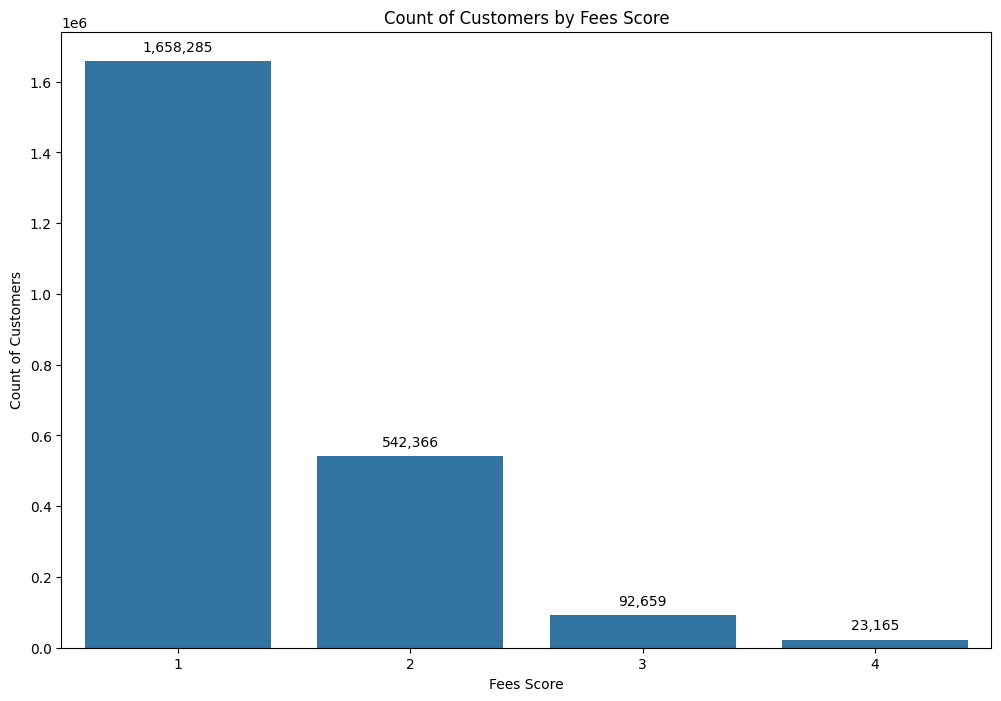

In [ ]:
# Create a bar plot of the count of customers by FM score
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='fees_score', data=df, order=sorted(df['fees_score'].unique()))
plt.title('Count of Customers by Fees Score')
plt.xlabel('Fees Score')
plt.ylabel('Count of Customers')

# Annotate the bars with the count values
for p in ax.patches:
    ax.annotate(format(int(p.get_height()), ','),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points')

plt.show()

In [ ]:
filtered_df = df[df['fees_score'] == 4]

filtered_df

,uid,occupation,city,province,age,gender,monetary,frequency,fees,basket_size,fees_score,segment
239,2768973,profesional,Kab. Langkat,Sumatera Utara,28,Male,9.364041e+10,536,1.741589e+07,1.747023e+08,4,Top Users
420,2296360,pelajar/mahasiswa,Kab. Tuban,Jawa Timur,23,Male,7.248648e+09,3276,1.618802e+07,2.212652e+06,4,Top Users
583,477963,pelajar/mahasiswa,Kota Palangka Raya,Kalimantan Tengah,29,Male,8.820313e+09,167,1.771119e+07,5.281624e+07,4,Top Users
791,159598,wiraswasta,Kab. Bantul,Di Yogyakarta,33,Male,1.655625e+10,2911,1.446067e+07,5.687479e+06,4,Top Users
828,6341374,pelajar/mahasiswa,Kab. Nganjuk,Jawa Timur,29,Female,2.236561e+11,749,1.069073e+07,2.986062e+08,4,Top Users
...,...,...,...,...,...,...,...,...,...,...,...,...
2316241,4821403,wiraswasta,Kota Tangerang Selatan,Banten,41,Male,1.969297e+10,582,4.128980e+07,3.383672e+07,4,Top Users
2316334,4032962,wiraswasta,Kota Tangerang Selatan,Banten,59,Male,2.019957e+10,508,2.595869e+07,3.976293e+07,4,Top Users
2316352,2707856,wiraswasta,Kota Tangerang Selatan,Banten,45,Male,3.833015e+09,132,9.579401e+06,2.903799e+07,4,Top Users
2316415,1049261,wiraswasta,Kota Tangerang Selatan,Banten,46,Male,1.213593e+10,102,2.981154e+07,1.189797e+08,4,Top Users


In [ ]:
# Create summary table
summary = df['segment'].value_counts().reset_index()
summary.columns = ['Segment', 'Number of Users']
summary['Percentage'] = (summary['Number of Users'] / summary['Number of Users'].sum()) * 100

# Display summary table
summary

,Segment,Number of Users,Percentage
0,Low Users,1658285,71.586570
1,Average Users,542366,23.413419
2,Valuable Users,92659,4.000000
3,Top Users,23165,1.000011


In [ ]:
# Calculate the average recency for each segment
avg_frequency_per_segment = df.groupby('segment')['frequency'].mean().reset_index()

# Display the result
avg_frequency_per_segment

,segment,frequency
0,Average Users,242.505476
1,Low Users,31.881620
2,Top Users,3695.773581
3,Valuable Users,919.096645


In [ ]:
# Calculate the average recency for each segment
avg_frequency_per_segment = df.groupby('segment')['frequency'].mean().reset_index()

# Display the result
avg_frequency_per_segment

,segment,frequency
0,Average Users,242.505476
1,Low Users,31.881620
2,Top Users,3695.773581
3,Valuable Users,919.096645


In [ ]:
# Calculate the average recency for each segment
max_frequency_per_segment = df.groupby('segment')['frequency'].max().reset_index()

# Display the result
max_frequency_per_segment

,segment,frequency
0,Average Users,787585
1,Low Users,152774
2,Top Users,5370152
3,Valuable Users,566068


In [ ]:
# Calculate the average recency for each segment
avg_basket_per_segment = df.groupby('segment')['basket_size'].mean().reset_index()

# Display the result
avg_basket_per_segment

,segment,basket_size
0,Average Users,3.016050e+06
1,Low Users,4.082190e+05
2,Top Users,4.110565e+07
3,Valuable Users,1.287375e+07


In [ ]:
# Calculate the average recency for each segment
min_basket_per_segment = df.groupby('segment')['basket_size'].min().reset_index()

# Display the result
min_basket_per_segment

,segment,basket_size
0,Average Users,7660.963175
1,Low Users,426.296712
2,Top Users,33672.987334
3,Valuable Users,17140.565950


In [ ]:
# Calculate the average recency for each segment
max_basket_per_segment = df.groupby('segment')['basket_size'].max().reset_index()

# Display the result
max_basket_per_segment

,segment,basket_size
0,Average Users,1.181279e+09
1,Low Users,2.763600e+09
2,Top Users,1.329557e+10
3,Valuable Users,1.653137e+09


In [ ]:
# Calculate the average recency for each segment
avg_fees_per_segment = df.groupby('segment')['fees'].mean().reset_index()

# Display the result
avg_fees_per_segment

,segment,fees
0,Average Users,2.187472e+05
1,Low Users,4.740954e+03
2,Top Users,4.086036e+07
3,Valuable Users,2.914863e+06


In [ ]:
# Calculate the average recency for each segment
min_fees_per_segment = df.groupby('segment')['fees'].min().reset_index()

# Display the result
min_fees_per_segment

,segment,fees
0,Average Users,3.000000e+04
1,Low Users,0.000000e+00
2,Top Users,8.406043e+06
3,Valuable Users,1.092258e+06


In [ ]:
# Calculate the average recency for each segment
max_fees_per_segment = df.groupby('segment')['fees'].max().reset_index()

# Display the result
max_fees_per_segment

,segment,fees
0,Average Users,1.092252e+06
1,Low Users,3.000000e+04
2,Top Users,3.600279e+10
3,Valuable Users,8.405920e+06


In [ ]:
# Calculate the average recency for each segment
avg_volume_per_segment = df.groupby('segment')['monetary'].mean().reset_index()

# Display the result
avg_volume_per_segment

,segment,monetary
0,Average Users,2.002179e+08
1,Low Users,7.311609e+06
2,Top Users,2.920905e+10
3,Valuable Users,2.286683e+09


In [ ]:
# Calculate the average recency for each segment
min_volume_per_segment = df.groupby('segment')['monetary'].min().reset_index()

# Display the result
min_volume_per_segment

,segment,monetary
0,Average Users,7.937182e+06
1,Low Users,1.000000e+04
2,Top Users,2.808206e+09
3,Valuable Users,3.649911e+08


In [ ]:
# Calculate the average recency for each segment
max_monetary_per_segment = df.groupby('segment')['monetary'].max().reset_index()

# Display the result
max_monetary_per_segment

,segment,monetary
0,Average Users,2.170191e+11
1,Low Users,1.250330e+12
2,Top Users,2.752640e+13
3,Valuable Users,4.803523e+11


In [ ]:
# Set display options to show full decimal values
pd.set_option('display.float_format', '{:.2f}'.format)

# Calculate the total volume for each segment
total_volume_per_segment = df.groupby('segment')['monetary'].sum().reset_index()

# Display the result
total_volume_per_segment

,segment,monetary
0,Average Users,108591380259820.56
1,Low Users,12124730931115.02
2,Top Users,676627701125564.12
3,Valuable Users,211881740566664.34


In [ ]:
# Set display options to show full decimal values
pd.set_option('display.float_format', '{:.2f}'.format)

# Calculate the total volume for each segment
total_fees_per_segment = df.groupby('segment')['fees'].sum().reset_index()

# Display the result
total_fees_per_segment

,segment,fees
0,Average Users,118641049440.88
1,Low Users,7861853033.74
2,Top Users,946530304328.18
3,Valuable Users,270088297215.42


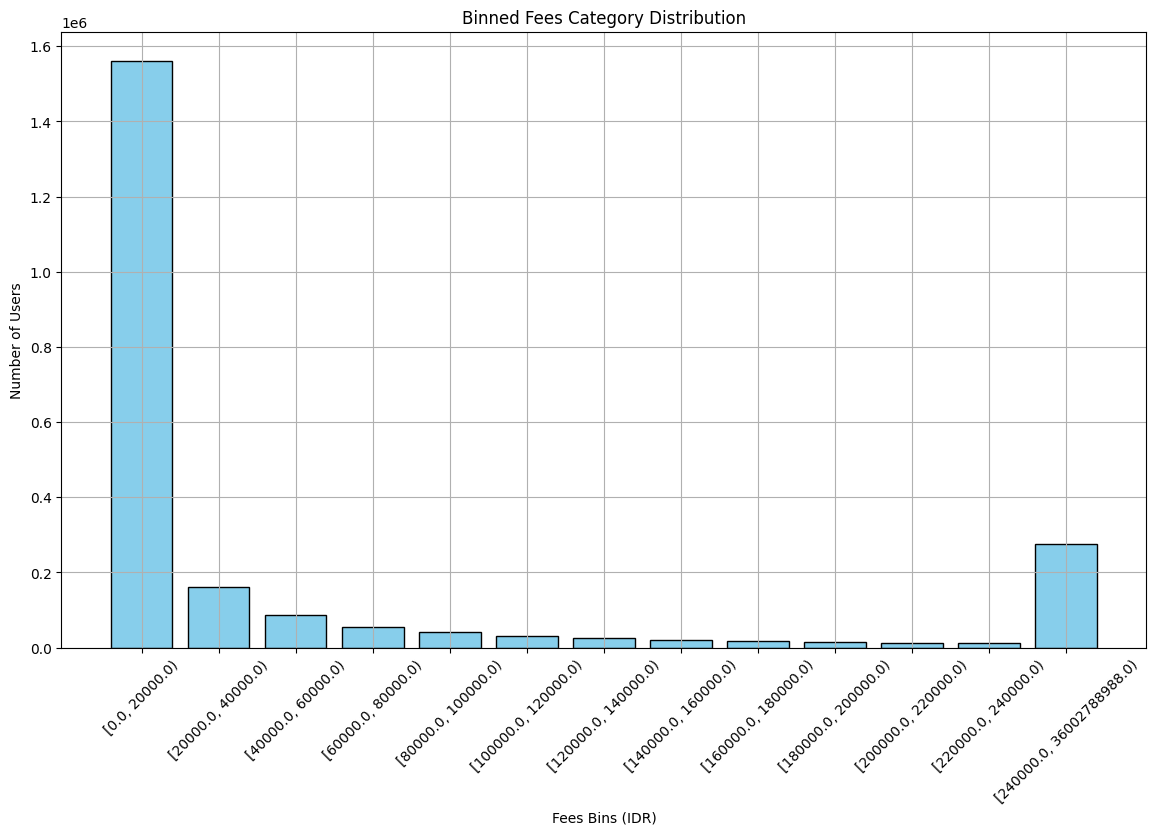

In [ ]:
# Determine the maximum value in the 'fees' column to create an appropriate upper bin limit
max_fees = df['fees'].max()

# Creating bins for fees to categorize them (make sure the last bin covers the max_fees)
bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, 200000, 220000, 240000, max_fees + 1]
df['fees_bins'] = pd.cut(df['fees'], bins=bins, right=False)  # right=False makes sure that the bins are inclusive on the left and exclusive on the right

# Counting the number of users in each bin
fees_binned_distribution = df['fees_bins'].value_counts().sort_index()

# Plotting the bar chart
plt.figure(figsize=(14, 8))
plt.bar(fees_binned_distribution.index.astype(str), fees_binned_distribution.values, color='skyblue', edgecolor='black')
plt.title('Binned Fees Category Distribution')
plt.xlabel('Fees Bins (IDR)')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

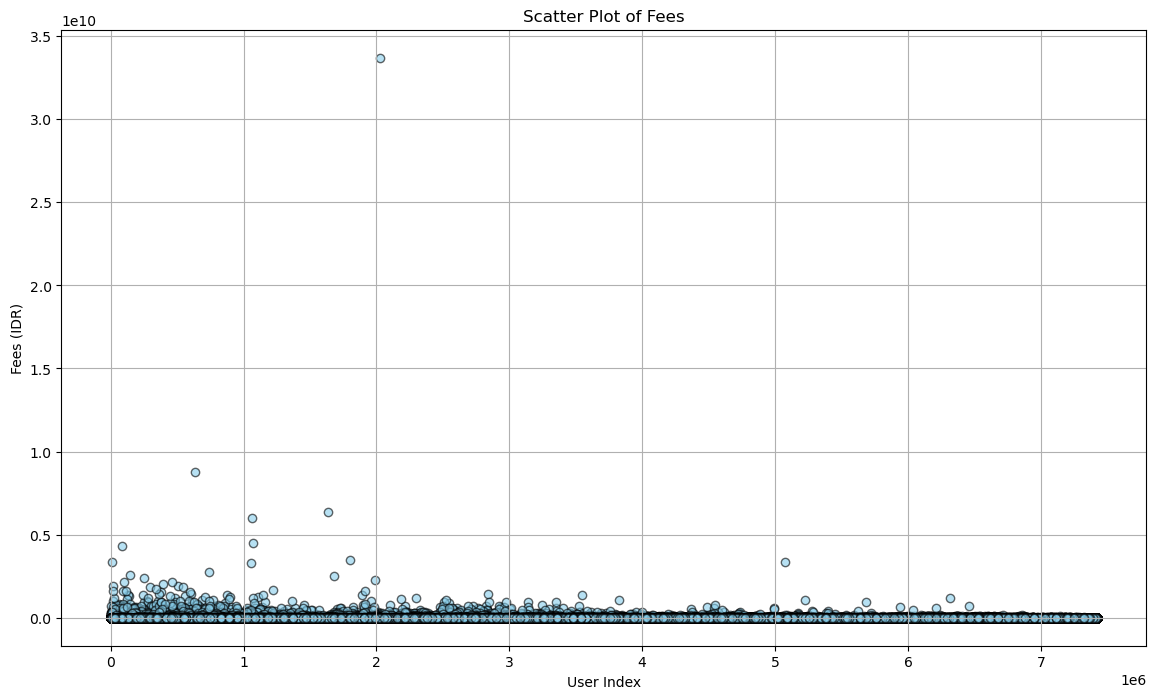

In [ ]:
# Creating the scatter plot
plt.figure(figsize=(14, 8))
plt.scatter(df.uid, df['fees'], alpha=0.6, color='skyblue', edgecolor='black')

# Adding plot details
plt.title('Scatter Plot of Fees')
plt.xlabel('User Index')
plt.ylabel('Fees (IDR)')
plt.grid(True)

# Display the plot
plt.show()

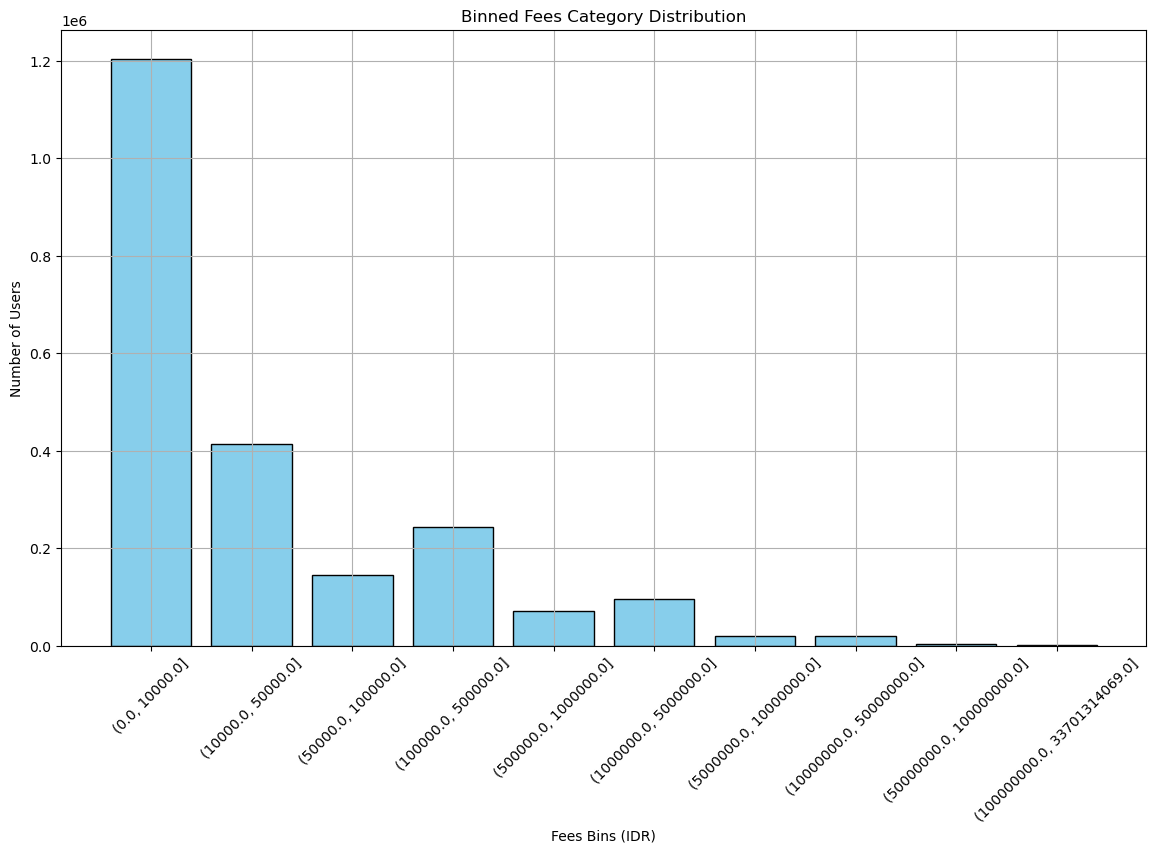

In [ ]:
# Categorize the 'fees' data into bins
bins = [0, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000, 50000000, 100000000, df['fees'].max()]
df['fees_category'] = pd.cut(df['fees'], bins=bins)

# Counting the number of users in each bin
fees_binned_distribution = df['fees_category'].value_counts().sort_index()

# Plotting the bar chart
plt.figure(figsize=(14, 8))
plt.bar(fees_binned_distribution.index.astype(str), fees_binned_distribution.values, color='skyblue', edgecolor='black')
plt.title('Binned Fees Category Distribution')
plt.xlabel('Fees Bins (IDR)')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

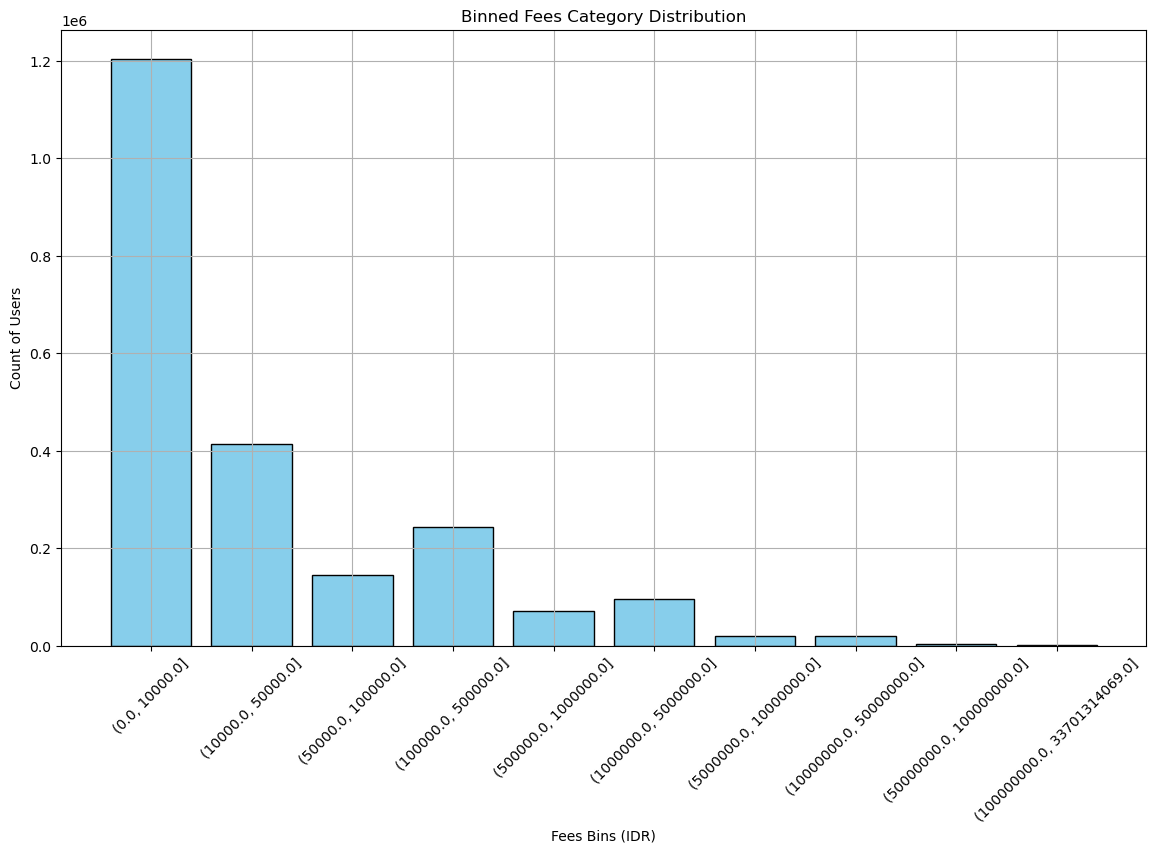

In [ ]:
# Determine the max value in the 'fees' column
fees_size = df['fees'].max()

# Creating bins for fees to categorize them, ensuring the max value is included
fees_bins = [0, 10000, 50000, 100000, 500000, 1000000, 5000000, 10000000, 50000000, 100000000, fees_size]
df['fee_bins'] = pd.cut(df['fees'], bins=fees_bins)

# Counting the number of users in each bin
fees_binned_distribution = df['fee_bins'].value_counts().sort_index()

# Plotting the bar chart for fees distribution
plt.figure(figsize=(14, 8))
plt.bar(fees_binned_distribution.index.astype(str), fees_binned_distribution.values, color='skyblue', edgecolor='black')
plt.title('Binned Fees Category Distribution')
plt.xlabel('Fees Bins (IDR)')
plt.ylabel('Count of Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:

# Calculate the percentiles for fees
fees_percentiles = df['fees'].quantile([0.7011010, 0.95, 0.99]).tolist()

# Define the percentile bins based on the calculated percentiles
percentile_bins = [-float('inf')] + fees_percentiles + [float('inf')]

# Define labels for the percentile ranges
percentile_labels = ['<= 30.000', '> 30.000 and <= 1263338', '> 1.263.338 and <= 9.897.290', '> 9.897.290']

# Assign users to percentile ranges
df['fees_percentile_range'] = pd.cut(df['fees'], bins=percentile_bins, labels=percentile_labels)

# Count the number of users in each percentile range
users_per_percentile = df['fees_percentile_range'].value_counts().sort_index().reset_index()
users_per_percentile.columns = ['Percentile Range', 'Number of Users']

# Display the result
users_per_percentile


,Percentile Range,Number of Users
0,<= 30.000,1682330
1,> 30.000 and <= 1263338,597243
2,> 1.263.338 and <= 9.897.290,95982
3,> 9.897.290,23996


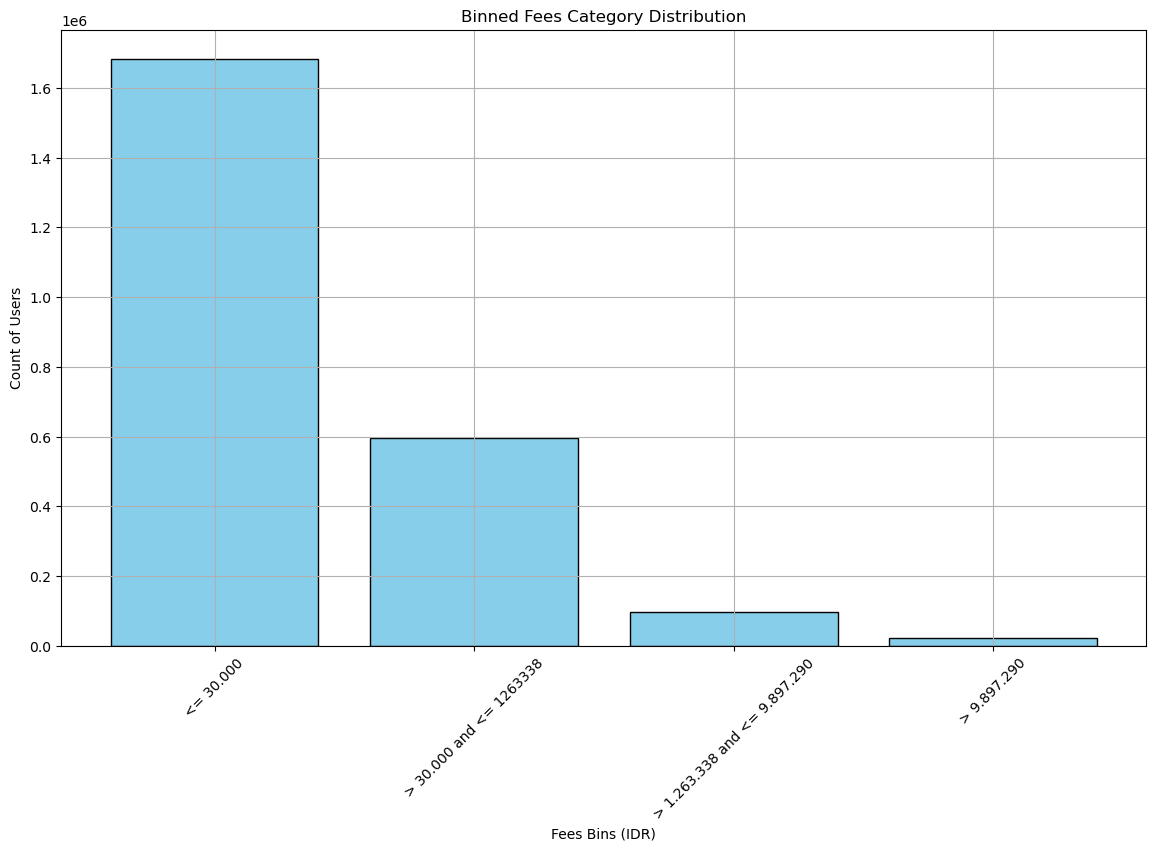

In [ ]:


# Counting the number of users in each bin
fees_binned_distribution = df['fees_percentile_range'].value_counts().sort_index()

# Plotting the bar chart for fees distribution
plt.figure(figsize=(14, 8))
plt.bar(fees_binned_distribution.index.astype(str), fees_binned_distribution.values, color='skyblue', edgecolor='black')
plt.title('Binned Fees Category Distribution')
plt.xlabel('Fees Bins (IDR)')
plt.ylabel('Count of Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()